In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from integrative_post_gwas.simulate_ehr import main as do_ehr_simulation
from integrative_post_gwas.ehr_utils import plot_real_vs_generated, set_manual_inputs, load_trait_csv

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

%load_ext autoreload
%autoreload 2

In [55]:
import importlib.metadata as m
if not m.version("eir-dl").startswith("0.24"):
    !uv pip install "git+https://github.com/arnor-sigurdsson/EIR.git@61adf0"

Using Python 3.13.1 environment at: /Users/txb777/Projects/phd/integrative_post_gwas_methods_course/.venv
Resolved 122 packages in 1.81s                                       
Uninstalled 1 package in 71ms
Installed 1 package in 25ms git+https://github.com/arnor-sig
 - eir-dl==0.23.0 (from git+https://github.com/arnor-sigurdsson/EIR.git@b959bfa4393763cc7b3ebeb8277b5b8802daeab9)
 + eir-dl==0.24.0 (from git+https://github.com/arnor-sigurdsson/EIR.git@61adf0263e1efb6664061f25f3caf1f753053807)


## Data Setup and Simulation

In [2]:
df_labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {df_labels.shape}")
display(df_labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Data Simulation

As we don't have real EHR data, we are going to simulate 

In [3]:
do_ehr_simulation(input_root=Path(".."), output_folder=Path("../reference_data/eir-transformer"))

In [4]:
df_seq_train = pd.read_csv("../reference_data/eir-transformer/df_ehr.csv", index_col=0)

In [5]:
df_seq_train.head(5)

,Sequence
ID,
10002_0,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...
10002_1,SEX_1 [VISIT_START] AGE_62 LAB_HDL_cholesterol...
10002_2,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...
10002_3,SEX_1 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
10002_4,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...


In [6]:
print(df_seq_train.iloc[0]['Sequence'])

SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol_36% LAB_LDL_Cholesterol_86% LAB_Total_Triglycerides_64% [VISIT_END] [SEP] [VISIT_START] AGE_66 LAB_HDL_cholesterol_40% LAB_LDL_Cholesterol_92% LAB_Total_Triglycerides_68% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_69 LAB_HDL_cholesterol_36% LAB_LDL_Cholesterol_90% LAB_Total_Triglycerides_76% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_73 LAB_HDL_cholesterol_40% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_70% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_74 LAB_HDL_cholesterol_34% LAB_LDL_Cholesterol_96% LAB_Total_Triglycerides_72% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_78 LAB_HDL_cholesterol_40% LAB_LDL_Cholesterol_92% LAB_Total_Triglycerides_66% DX_E11 [VISIT_END]


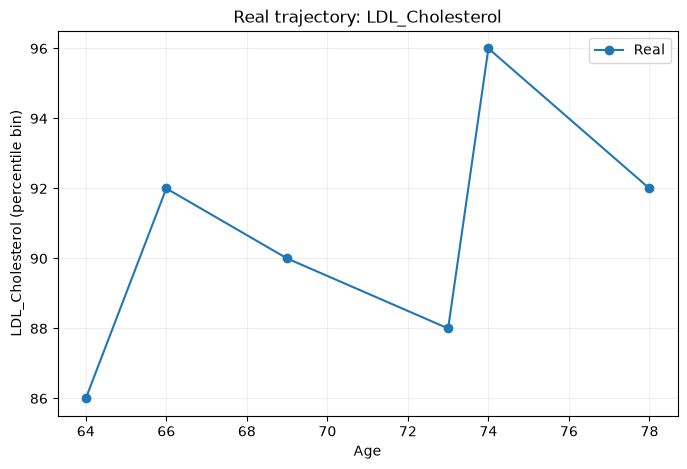

In [7]:
plot_real_vs_generated(real_seq=df_seq_train.iloc[0]['Sequence'], generated_seq=None, lab="LDL_Cholesterol")

# Training

In [8]:
!eirtrain \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence.yaml"

13:31:00 - INFO - eir.train_utils.utils - Global random seed set to 0.
13:31:01 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
13:31:01 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
13:31:01 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 1400 IDs read from file.
13:31:01 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
13:31:01 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 11200it [00:00, 6662346.45it/s]
13:31:01 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
13:31:01 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
13:31:01 

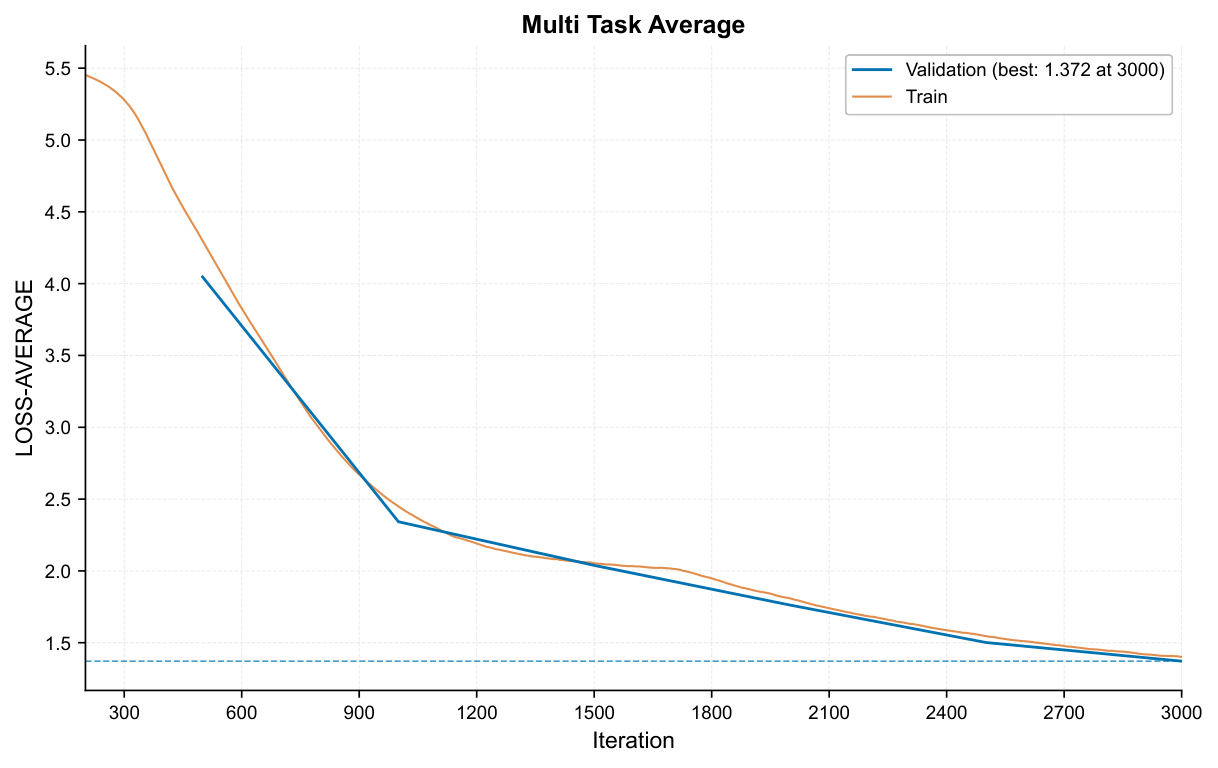

In [9]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing sequence generation

In [10]:
df_test_first_visit = pd.read_csv("../reference_data/eir-transformer/df_ehr_test_first_visit.csv", index_col=["ID"])

In [11]:
test_sample_index = 0

In [12]:
df_test_first_visit.iloc[test_sample_index].Sequence

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END]'

In [13]:
prompt = df_test_first_visit["Sequence"].iloc[test_sample_index]
current_id = df_test_first_visit.index[test_sample_index]
print(prompt)

SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END]


In [14]:
set_manual_inputs(prompts=prompt)

In [17]:
!eirpredict \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence_test.yaml" \
    --model_path "../runs/ehr_transformer/saved_models/ehr_transformer_checkpoint_3000_perf-average=-0.3718.pt" \
    --output_folder "../runs/ehr_transformer/test_set_predictions"

13:34:06 - INFO - eir.train_utils.utils - Global random seed set to 0.
13:34:06 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
13:34:06 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
13:34:06 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
13:34:06 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_

## Analyzing test performance

In [20]:
with open("../runs/ehr_transformer/test_set_predictions/results/ehr/ehr/samples/0/manual/10_generated.txt") as infile:
    generated = infile.read()

In [21]:
generated

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END] [SEP] [VISIT_START] AGE_62 LAB_HDL_cholesterol_98% LAB_LDL_Cholesterol_100% LAB_Total_Triglycerides_12% [VISIT_END] [SEP] [VISIT_START] AGE_65 LAB_HDL_cholesterol_96% LAB_LDL_Cholesterol_94% LAB_Total_Triglycerides_8% [VISIT_END] [SEP] [VISIT_START] AGE_69 LAB_HDL_cholesterol_100% LAB_LDL_Cholesterol_100% LAB_Total_Triglycerides_20% [VISIT_END]'

In [22]:
df_test_full = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col=["ID"])

In [23]:
df_test_full.loc[current_id]["Sequence"]

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END] [SEP] [VISIT_START] AGE_60 LAB_HDL_cholesterol_94% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_26% [VISIT_END] [SEP] [VISIT_START] AGE_64 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_92% LAB_Total_Triglycerides_26% DX_I10 DX_I25 [VISIT_END]'

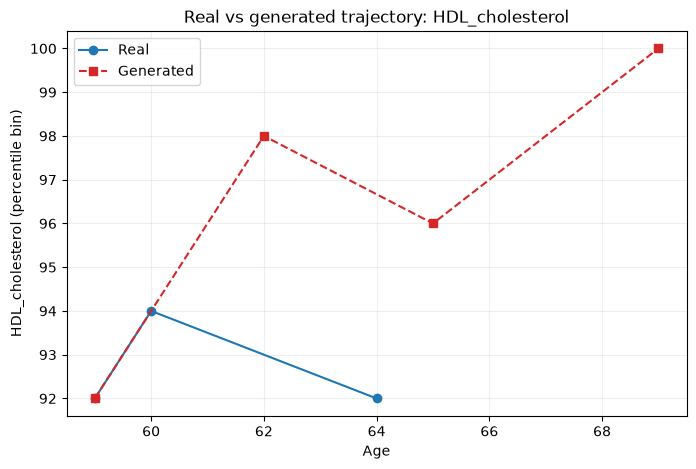

In [24]:
real_seq = df_test_full.loc[current_id]["Sequence"]
plot_real_vs_generated(real_seq=real_seq, generated_seq=generated, lab="HDL_cholesterol", disease="E11")

# Training with GRS as additional inputs

In [25]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

df_grs = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {df_grs.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")

df_grs.index = df_grs.index.astype(str)

display(df_grs.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542772,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.537926,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361750,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.547020,76.31497,6.289234,52.096508,23.333853,37.992416
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930590,76.097400,75.78765,6.923183,51.953293,26.081810,37.976200
10007,23.979660,45.518280,87.363420,1.639348,1.566334,1.016251,0.852204,24.755083,9.717244,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.782000,70.52157,6.385489,49.508488,22.894983,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538030,78.507370,78.36777,6.650043,52.501266,23.214048,38.252075


In [26]:
df_seq_test = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col="ID")

In [27]:
df_seq = pd.concat([df_seq_train, df_seq_test])

In [28]:
df_seq_test

,Sequence
ID,
10027_0,SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol...
10027_1,SEX_2 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
10027_2,SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol...
10027_3,SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol...
10027_4,SEX_2 [VISIT_START] AGE_60 LAB_HDL_cholesterol...
...,...
11591_5,SEX_2 [VISIT_START] AGE_60 LAB_HDL_cholesterol...
11591_6,SEX_2 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
11591_7,SEX_2 [VISIT_START] AGE_63 LAB_HDL_cholesterol...


In [29]:
import pandas as pd
import numpy as np

df_seq['base_id'] = df_seq.index.str.split('_').str[0]

df_expanded = df_seq[['base_id']].merge(
    df_grs, 
    left_on='base_id', 
    right_index=True, 
    how='left'
)

numeric_cols = df_expanded.select_dtypes(include=[np.number]).columns

noise_factor = 0.01 

for col in numeric_cols:
    noise = np.random.normal(0, df_expanded[col].std() * noise_factor, size=len(df_expanded))
    df_expanded[col] = df_expanded[col] + noise

df_grs_matched = df_expanded.drop(columns=['base_id'])

In [30]:
df_grs_train = df_grs_matched[df_grs_matched.index.isin(df_seq_train.index)]
df_grs_test = df_grs_matched[df_grs_matched.index.isin(df_seq_test.index)]

In [31]:
df_grs_train.to_csv("../reference_data/eir-transformer/df_grs.csv")
df_grs_test.to_csv("../reference_data/eir-transformer/df_grs_test.csv")

In [32]:
import yaml

all_columns = [
    "Cholesterol",                    
    "LDL_direct",                     
    "Glycated_haemoglobin_HbA1c",     
    "Alanine_aminotransferase",
    "Aspartate_aminotransferase",
    "Gamma_glutamyltransferase",
    "Alkaline_phosphatase",
    "Albumin_BIOCH",
    "Total_protein",
    "Direct_bilirubin",
    "Total_bilirubin",
    "C_reactive_protein",
    "Urate",
    "Calcium",
    "Phosphate",
    "Creatinine_BIOCH",
    "Cystatin_C",
    "Urea",
    "IGF_1",
    "Vitamin_D",
    "Lipoprotein_A",
]

config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [33]:
config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs_test.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular_test.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [ ]:
!eirtrain \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs  "../configs/eir-transformer-with-grs/input_tabular.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence.yaml"

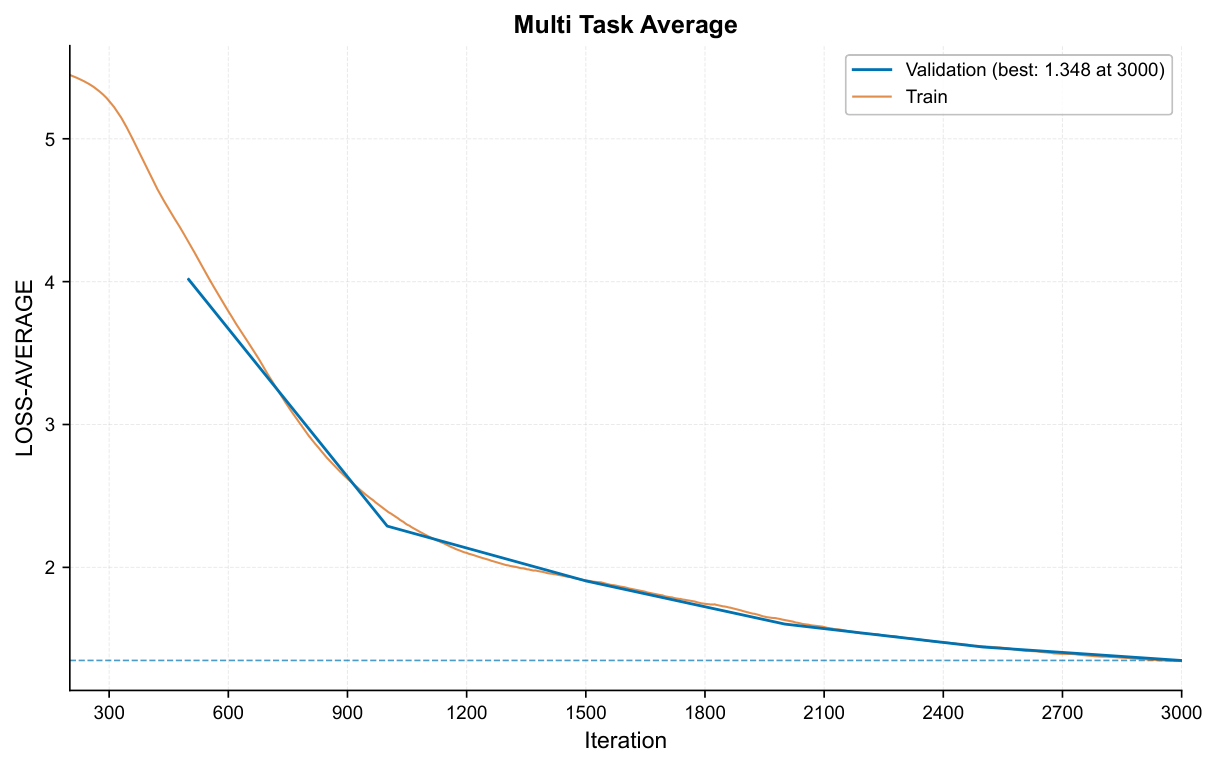

In [44]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer-with-grs/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing with GRS input

In [45]:
df_test_first_visit = pd.read_csv("../reference_data/eir-transformer/df_ehr_test_first_visit.csv", index_col=["ID"])

In [46]:
test_sample_index = 0

In [47]:
df_test_first_visit.iloc[test_sample_index].Sequence

'SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END]'

In [48]:
prompt = df_test_first_visit["Sequence"].iloc[test_sample_index]
current_id = df_test_first_visit.index[test_sample_index]
print(prompt)

SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_88% LAB_Total_Triglycerides_18% [VISIT_END]


In [49]:
current_base_id = current_id.split("_")[0]
tabular_input = df_grs.loc[current_base_id, all_columns].to_dict()

In [50]:
tabular_input

{'Cholesterol': 6.1145873,
 'LDL_direct': 3.7932913,
 'Glycated_haemoglobin_HbA1c': 36.74147,
 'Alanine_aminotransferase': 26.33017,
 'Aspartate_aminotransferase': 27.550789,
 'Gamma_glutamyltransferase': 38.039497,
 'Alkaline_phosphatase': 79.44806,
 'Albumin_BIOCH': 45.703136,
 'Total_protein': 71.72162,
 'Direct_bilirubin': 3.3085146,
 'Total_bilirubin': 19.51425,
 'C_reactive_protein': 2.1354513,
 'Urate': 301.092,
 'Calcium': 2.3919413,
 'Phosphate': 1.1971753,
 'Creatinine_BIOCH': 75.11925,
 'Cystatin_C': 0.8391408,
 'Urea': 5.454428,
 'IGF_1': 20.05275,
 'Vitamin_D': 49.109905,
 'Lipoprotein_A': 40.11286}

In [51]:
set_manual_inputs(prompts=prompt,
                  config_path="../configs/eir-transformer-with-grs/output_sequence_test.yaml",
                  tabular=tabular_input)

In [52]:
!eirpredict \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs "../configs/eir-transformer-with-grs/input_tabular_test.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence_test.yaml" \
    --model_path "../runs/ehr_transformer-with-grs/saved_models/ehr_transformer-with-grs_checkpoint_3000_perf-average=-0.3483.pt" \
    --output_folder "../runs/ehr_transformer-with-grs/test_set_predictions" 

13:39:26 - INFO - eir.train_utils.utils - Global random seed set to 0.
13:39:26 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
13:39:26 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
13:39:26 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
13:39:26 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_

In [53]:
with open("../runs/ehr_transformer-with-grs/test_set_predictions/results/ehr/ehr/samples/0/manual/0_generated.txt") as infile:
    generated = infile.read()

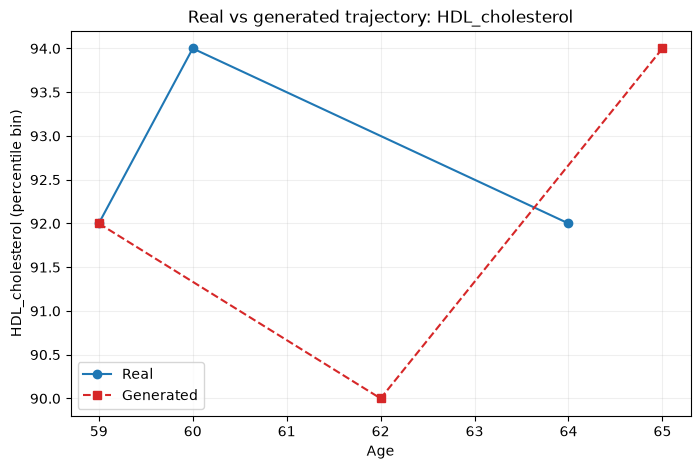

In [54]:
real_seq = df_test_full.loc[current_id]["Sequence"]
plot_real_vs_generated(real_seq=real_seq, generated_seq=generated, lab="HDL_cholesterol", disease="E11")